# Assay walkthrough: measuring the noise floor of an LLM eval

**Assay** is a statistics and audit layer for the eval harnesses you already run.
This notebook reproduces every headline figure on the project site, end to end,
from the shipped example fixtures. Run the cells top to bottom and you will
regenerate the exact PNGs in `results/figures/` and the numeric outputs in
`results/`.

What you will reproduce:

1. **The reconciler** : one set of *frozen* GSM8K generations scored two ways, with
   the accuracy gap attributed to the extraction rule that caused it.
2. **Error bars and clustering** : why a naive standard error understates
   uncertainty when items share a source, and how much (here ~2.5x).
3. **Power and the noise floor** : the smallest gap an eval of size *n* can resolve,
   and why pairing your comparisons buys you most of it back.

**To run**
```bash
python -m pip install -e ".[notebook]"
jupyter nbconvert --to notebook --execute notebooks/assay_walkthrough.ipynb
# or open it in Jupyter and Run All
```

**Honesty note.** The files in `examples/` are synthetic *illustrative* fixtures that
use the real on-disk schema of the inputs Assay consumes. They exercise the exact
code path but are not real model outputs, so the numbers here demonstrate the
*method*, not a finding. The illustrative GSM8K gap is deliberately large (~33 pts)
to make the mechanism obvious; the real reproduction on actual generations recovers
the documented ~8-point strict-vs-flexible gap.

In [1]:
# --- setup -----------------------------------------------------------------
import json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter

import assay
from assay import stats
from assay.ingest import load_lm_eval_samples
from assay.reconcile import reconcile_gsm8k
from assay.check import check_samples

print("assay version:", assay.__version__)

# Resolve the repo root whether this runs from the repo root or from notebooks/.
ROOT = Path.cwd()
if not (ROOT / "pyproject.toml").exists():
    ROOT = ROOT.parent
EXAMPLES = ROOT / "examples"
RESULTS = ROOT / "results"
FIGS = RESULTS / "figures"
DOCS_FIGS = ROOT / "docs" / "figures"
for d in (RESULTS, FIGS, DOCS_FIGS):
    d.mkdir(parents=True, exist_ok=True)

# One consistent visual style for every figure (white ground so the PNGs read
# well on the site in both light and dark themes, where they sit on a white card).
INK, TEAL, MUTED, WARN, CRIT, GRID = "#10171C", "#0C8C7E", "#63727C", "#B26E12", "#C24248", "#D6DDD9"
plt.rcParams.update({
    "figure.facecolor": "white", "axes.facecolor": "white",
    "axes.edgecolor": MUTED, "axes.labelcolor": INK, "text.color": INK,
    "xtick.color": MUTED, "ytick.color": MUTED, "axes.grid": True,
    "grid.color": GRID, "grid.linewidth": 0.8, "font.size": 11,
    "axes.titlesize": 12.5, "axes.titleweight": "bold", "figure.dpi": 150,
    "savefig.bbox": "tight", "axes.spines.top": False, "axes.spines.right": False,
})

def save(fig, name):
    """Save a figure to results/figures and mirror it into docs/figures for the site."""
    for folder in (FIGS, DOCS_FIGS):
        fig.savefig(folder / name, dpi=150)
    print("saved", name)

summary = {"note": "Illustrative fixtures. Numbers demonstrate the method, not a finding."}


assay version: 0.1.0


## 1. The reconciler: same generations, two parsers

lm-evaluation-harness ships two answer extractors for GSM8K that run on the *same*
model output:

* `strict-match` requires the canonical `#### <number>` delimiter.
* `flexible-extract` takes the last number-like token anywhere in the text.

If the model reasons in prose and forgets the delimiter, strict-match scores it
wrong while flexible-extract recovers the answer. The model never changed; the
regex did. `assay reconcile` replays frozen generations through both paths and
attributes every point of the gap to the rule responsible.

In [2]:
# Load the frozen generations (the model does not re-run) and reconcile.
rows = [json.loads(l) for l in open(EXAMPLES / "gsm8k_frozen.jsonl") if l.strip()]
res = reconcile_gsm8k(rows)

# The strict-vs-flexible delta is itself a paired comparison between two *scorers*
# on identical items, so we can put a p-value on it with the same machinery.
paired = stats.paired_mcnemar(res.strict_scores, res.flexible_scores)

print(f"frozen generations : {res.n}")
print(f"strict-match       : {res.strict_acc*100:6.2f}%   [deterministic]")
print(f"flexible-extract   : {res.flexible_acc*100:6.2f}%   [deterministic]")
print(f"delta              : {res.delta*100:+6.2f} pts")
print(f"flexible recovered : {res.flexible_recovered}  (strict missed the '####' delimiter)")
print(f"flexible fooled    : {res.flexible_fooled}  (grabbed a trailing distractor)")
print(f"paired McNemar p   : {paired.p_value:.4g}   [statistically estimated]")

summary["reconcile"] = {
    "n": res.n, "strict_acc": res.strict_acc, "flexible_acc": res.flexible_acc,
    "delta": res.delta, "recovered": res.flexible_recovered, "fooled": res.flexible_fooled,
    "paired_p_value": paired.p_value,
}
json.dump({**summary["reconcile"], "flips": [vars(f) for f in res.flips]},
          open(RESULTS / "reconcile_gsm8k.json", "w"), indent=2)


frozen generations : 24
strict-match       :  54.17%   [deterministic]
flexible-extract   :  87.50%   [deterministic]
delta              : +33.33 pts
flexible recovered : 10  (strict missed the '####' delimiter)
flexible fooled    : 2  (grabbed a trailing distractor)
paired McNemar p   : 0.03857   [statistically estimated]


saved fig3_reconciler.png


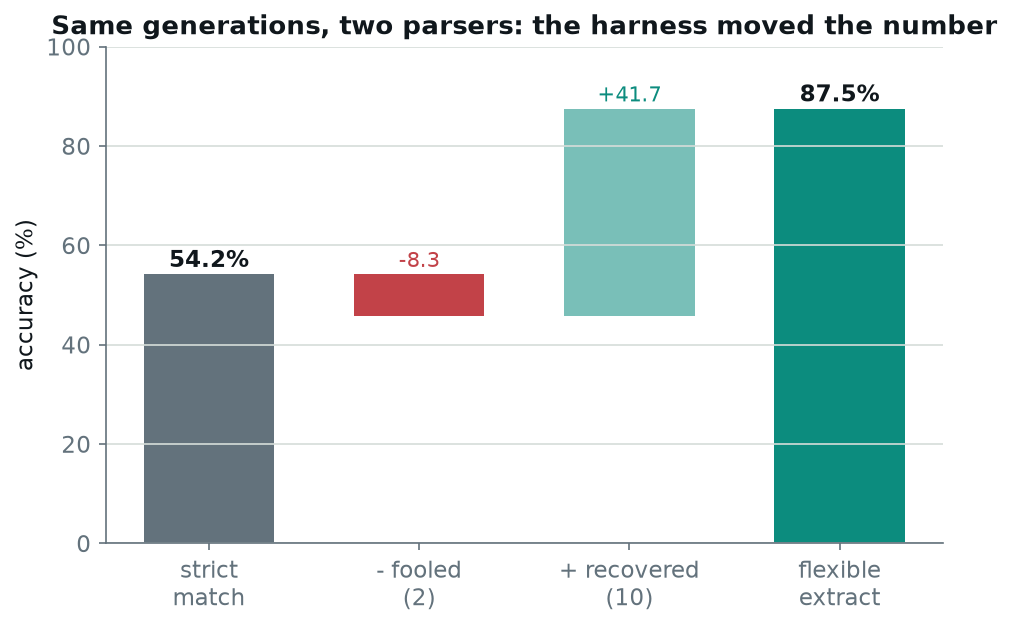

In [3]:
# Figure 3 : a waterfall from strict to flexible accuracy. The honest picture is
# that flexible-extract *recovers* far more than it is *fooled* by, but both happen.
strict_pct = res.strict_acc * 100
flex_pct = res.flexible_acc * 100
rec_pts = res.flexible_recovered / res.n * 100
fooled_pts = res.flexible_fooled / res.n * 100
mid = strict_pct - fooled_pts  # after removing the items flexible loses

fig, ax = plt.subplots(figsize=(7.2, 4.3))
ax.bar(0, strict_pct, color=MUTED, width=0.62)
ax.bar(1, fooled_pts, bottom=mid, color=CRIT, width=0.62)          # lost going to flexible
ax.bar(2, rec_pts, bottom=mid, color=TEAL, width=0.62, alpha=0.55)  # gained going to flexible
ax.bar(3, flex_pct, color=TEAL, width=0.62)
for x, v in [(0, strict_pct), (3, flex_pct)]:
    ax.text(x, v + 1.5, f"{v:.1f}%", ha="center", fontweight="bold")
ax.text(1, mid + fooled_pts + 1.5, f"-{fooled_pts:.1f}", ha="center", color=CRIT, fontsize=10)
ax.text(2, mid + rec_pts + 1.5, f"+{rec_pts:.1f}", ha="center", color=TEAL, fontsize=10)
ax.set_xticks(range(4))
ax.set_xticklabels(["strict\nmatch", f"- fooled\n({res.flexible_fooled})",
                    f"+ recovered\n({res.flexible_recovered})", "flexible\nextract"])
ax.set_ylabel("accuracy (%)")
ax.set_ylim(0, 100)
ax.set_title("Same generations, two parsers: the harness moved the number")
ax.grid(axis="x", visible=False)
save(fig, "fig3_reconciler.png"); plt.show()


In [4]:
# The attribution table: every flip, and why it flipped. This is the audit trail.
print(f"{'id':>5}  {'gold':>5}  {'strict':>7}  {'flex':>5}   reason")
print("-" * 92)
for f in res.flips:
    print(f"{f.item_id:>5}  {str(f.gold):>5}  {str(f.strict_pred):>7}  {str(f.flexible_pred):>5}   {f.reason[:64]}")


   id   gold   strict   flex   reason
--------------------------------------------------------------------------------------------
 g001      3     None      3   no '####' delimiter emitted; strict-match found nothing, flexibl
 g003      5     None      5   no '####' delimiter emitted; strict-match found nothing, flexibl
 g005      8     None      8   no '####' delimiter emitted; strict-match found nothing, flexibl
 g007     29     None     29   no '####' delimiter emitted; strict-match found nothing, flexibl
 g009     48     None     48   no '####' delimiter emitted; strict-match found nothing, flexibl
 g011      7     None      7   no '####' delimiter emitted; strict-match found nothing, flexibl
 g013     70     None     70   no '####' delimiter emitted; strict-match found nothing, flexibl
 g015     25       25      3   flexible grabbed trailing distractor '3'; strict matched the del
 g016     12       12      6   flexible grabbed trailing distractor '6'; strict matched the del
 g017

## 2. Error bars and clustering: naive SEs lie when items share a source

MMLU items are grouped by subject; DROP questions share a passage; SWE-bench tasks
share a repo. Scores within a group are correlated, so treating items as i.i.d.
understates the uncertainty. Assay defaults to a CR2 (Bell-McCaffrey) cluster-robust
standard error, with a pairs-cluster bootstrap as a cross-check when clusters are few.

The fixture below is 48 items across 6 subjects; some subjects are almost all right,
some almost all wrong. That within-subject correlation is exactly what a clustered SE
is built to capture.

In [5]:
# Load the lm-eval samples fixture and build the full check report.
records = load_lm_eval_samples(EXAMPLES / "sample_lm_eval.jsonl", cluster_field="subject")
report = check_samples(records)

s = [r.score for r in records]
keys = [r.cluster_key for r in records]
mean, naive_se = stats.mean_and_naive_se(s)
cr2 = stats.cluster_robust_se(s, keys, method="CR2")
boot = stats.cluster_bootstrap_se(s, keys, n_boot=4000, seed=0)

print(f"accuracy      : {mean:.4f}")
print(f"naive SE      : {naive_se:.4f}")
print(f"CR2 SE        : {cr2.cluster_se:.4f}   ({cr2.n_clusters} clusters)")
print(f"bootstrap SE  : {boot:.4f}")
print(f"SE inflation  : {cr2.inflation:.2f}x  (CR2 / naive)")

summary["clustering"] = {
    "accuracy": mean, "naive_se": naive_se, "cr2_se": cr2.cluster_se,
    "bootstrap_se": boot, "inflation": cr2.inflation, "n_clusters": cr2.n_clusters,
}
json.dump(report, open(RESULTS / "check_mmlu_fixture.json", "w"), indent=2)


accuracy      : 0.5625
naive SE      : 0.0724
CR2 SE        : 0.1790   (6 clusters)
bootstrap SE  : 0.1651
SE inflation  : 2.47x  (CR2 / naive)


saved fig2_error_bars.png


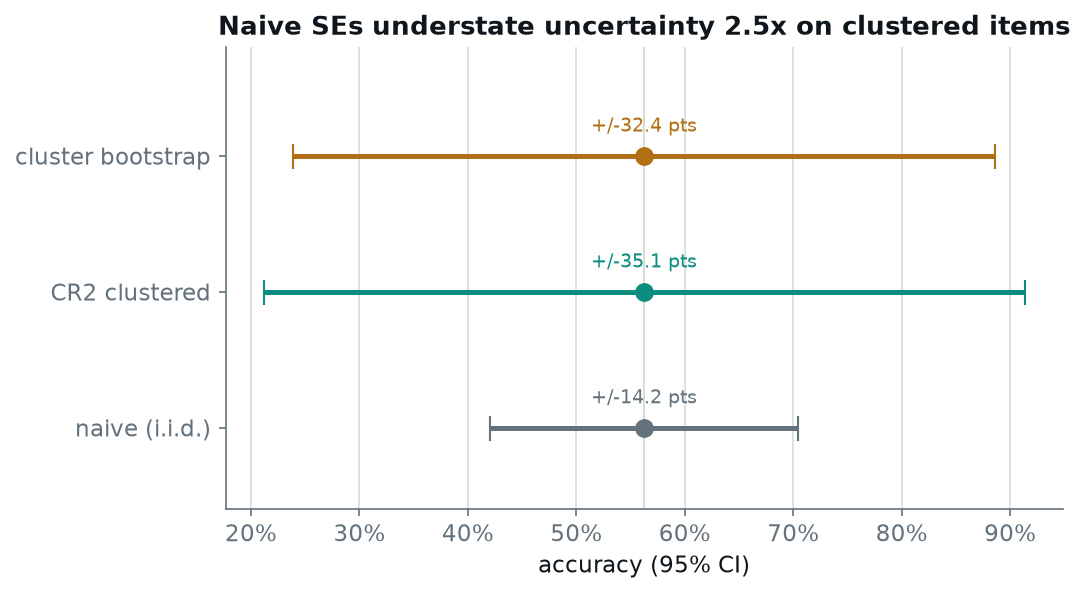

In [6]:
# Figure 2 : the same accuracy, three error bars. The naive CI is far too tight.
z = 1.959964
methods = [("naive (i.i.d.)", naive_se, MUTED),
           ("CR2 clustered", cr2.cluster_se, TEAL),
           ("cluster bootstrap", boot, WARN)]
fig, ax = plt.subplots(figsize=(7.2, 4.0))
for i, (label, se, color) in enumerate(methods):
    ax.errorbar(mean, i, xerr=z * se, fmt="o", color=color, capsize=6,
                elinewidth=2.4, markersize=8, label=label)
    ax.text(mean, i + 0.18, f"+/-{z*se*100:.1f} pts", ha="center", color=color, fontsize=9)
ax.axvline(mean, color=GRID, lw=1, zorder=0)
ax.set_yticks(range(len(methods)))
ax.set_yticklabels([m[0] for m in methods])
ax.set_ylim(-0.6, len(methods) - 0.2)
ax.set_xlabel("accuracy (95% CI)")
ax.xaxis.set_major_formatter(FuncFormatter(lambda v, _: f"{v*100:.0f}%"))
ax.set_title(f"Naive SEs understate uncertainty {cr2.inflation:.1f}x on clustered items")
ax.grid(axis="y", visible=False)
save(fig, "fig2_error_bars.png"); plt.show()


saved fig4_subject_clusters.png


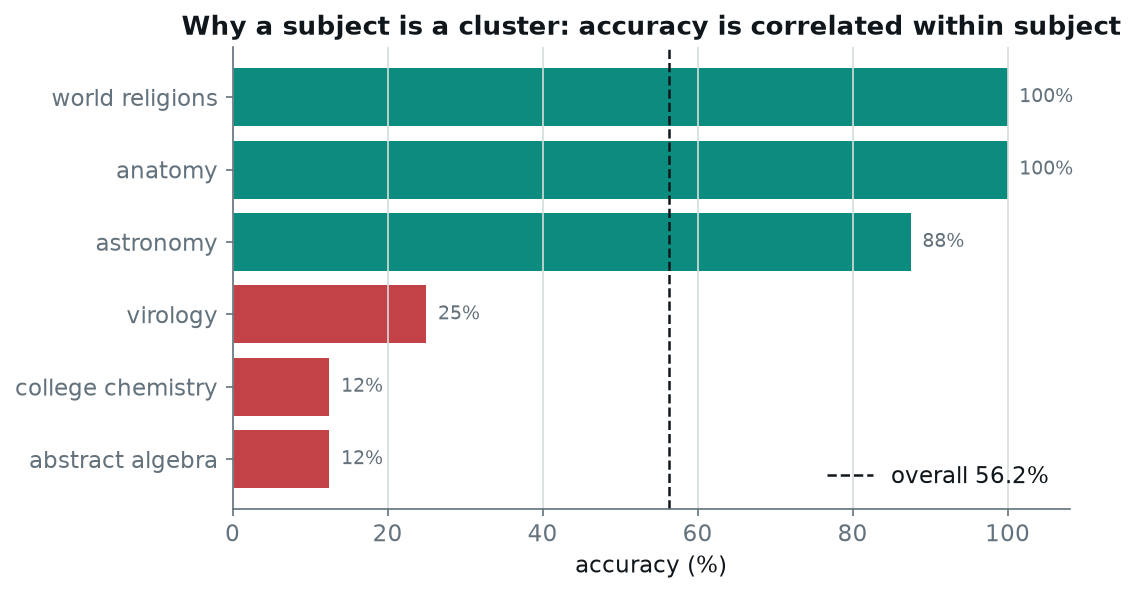

In [7]:
# Figure 4 : per-subject accuracy. Whole subjects move together, and that
# correlation is what the clustered SE captures (and the naive SE misses).
subjects, accs, ns = [], [], []
for k in dict.fromkeys(keys):
    vals = [sc for sc, kk in zip(s, keys) if kk == k]
    subjects.append(k.replace("_", " "))
    accs.append(100 * np.mean(vals))
    ns.append(len(vals))
order = np.argsort(accs)
subjects = [subjects[i] for i in order]; accs = [accs[i] for i in order]
colors = [CRIT if a < 40 else (WARN if a < 70 else TEAL) for a in accs]

fig, ax = plt.subplots(figsize=(7.2, 4.0))
ax.barh(subjects, accs, color=colors)
ax.axvline(mean * 100, color=INK, ls="--", lw=1.2, label=f"overall {mean*100:.1f}%")
for i, a in enumerate(accs):
    ax.text(a + 1.5, i, f"{a:.0f}%", va="center", fontsize=9, color=MUTED)
ax.set_xlim(0, 108)
ax.set_xlabel("accuracy (%)")
ax.set_title("Why a subject is a cluster: accuracy is correlated within subject")
ax.legend(loc="lower right", frameon=False)
ax.grid(axis="y", visible=False)
save(fig, "fig4_subject_clusters.png"); plt.show()


## 3. Power and the noise floor

The core promise: tell the user what the eval *cannot* see, before a token is spent.
The minimum detectable effect (MDE) follows Miller (arXiv:2411.00640, Eq 9):

$$\text{MDE} = (z_{1-\alpha/2} + z_{\text{power}})\,\frac{\sigma}{\sqrt{n}}$$

with the factor $(z_{1-\alpha/2}+z_{\text{power}})^2 = 7.85$ at $\alpha=0.05$, power $0.8$.

saved fig1_noise_floor_mde.png


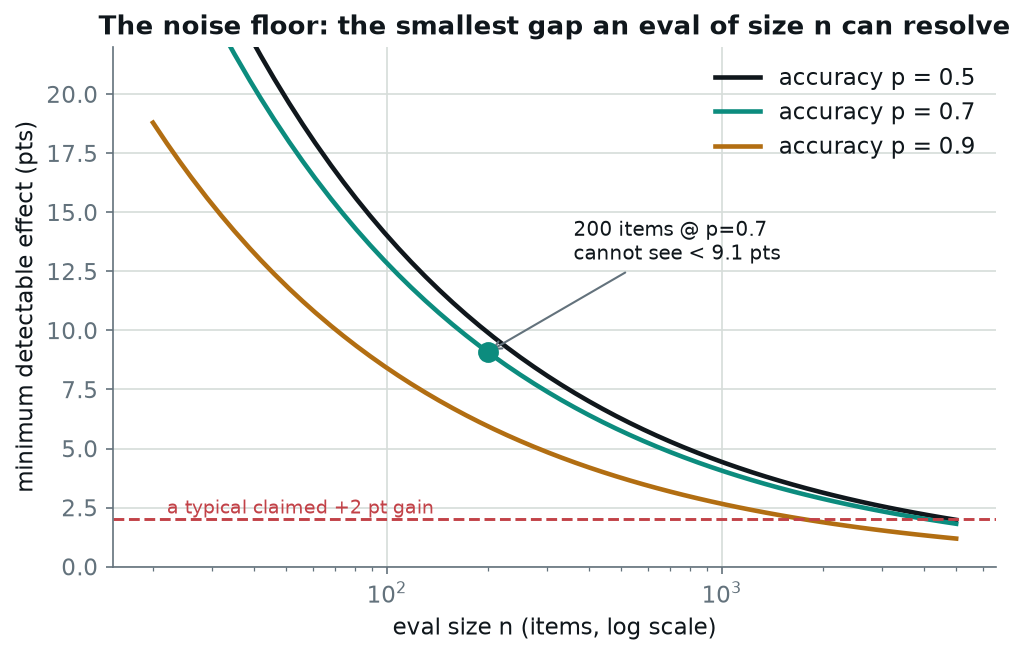

MDE at n=200, p=0.7: 9.08 pts


In [8]:
# Figure 1 (the hero): the noise floor. Smallest gap an n-item eval can resolve.
ns = np.unique(np.round(np.logspace(np.log10(20), np.log10(5000), 60)).astype(int))
fig, ax = plt.subplots(figsize=(7.6, 4.5))
for p, color in [(0.5, INK), (0.7, TEAL), (0.9, WARN)]:
    mde = [stats.mde_absolute(int(n), p) * 100 for n in ns]
    ax.plot(ns, mde, color=color, lw=2.2, label=f"accuracy p = {p}")
ax.axhline(2.0, color=CRIT, ls="--", lw=1.4)
ax.text(22, 2.25, "a typical claimed +2 pt gain", color=CRIT, fontsize=9)

n_mark = 200
mde200 = stats.mde_absolute(n_mark, 0.7) * 100
ax.plot([n_mark], [mde200], "o", color=TEAL, ms=9, zorder=5)
ax.annotate(f"200 items @ p=0.7\ncannot see < {mde200:.1f} pts",
            xy=(n_mark, mde200), xytext=(360, 13),
            arrowprops=dict(arrowstyle="->", color=MUTED), fontsize=9.5, color=INK)
ax.set_xscale("log"); ax.set_xlabel("eval size n (items, log scale)")
ax.set_ylabel("minimum detectable effect (pts)")
ax.set_ylim(0, 22)
ax.set_title("The noise floor: the smallest gap an eval of size n can resolve")
ax.legend(loc="upper right", frameon=False)
save(fig, "fig1_noise_floor_mde.png"); plt.show()

# Persist the MDE table as CSV for anyone who wants the raw numbers.
import csv
with open(RESULTS / "mde_table.csv", "w", newline="") as fh:
    w = csv.writer(fh); w.writerow(["n", "mde_p0.5_pts", "mde_p0.7_pts", "mde_p0.9_pts"])
    for n in ns:
        w.writerow([int(n)] + [round(stats.mde_absolute(int(n), p) * 100, 3) for p in (0.5, 0.7, 0.9)])
print("MDE at n=200, p=0.7:", round(mde200, 2), "pts")
summary["mde_n200_p0.7_pts"] = mde200


saved fig5_paired_required_n.png


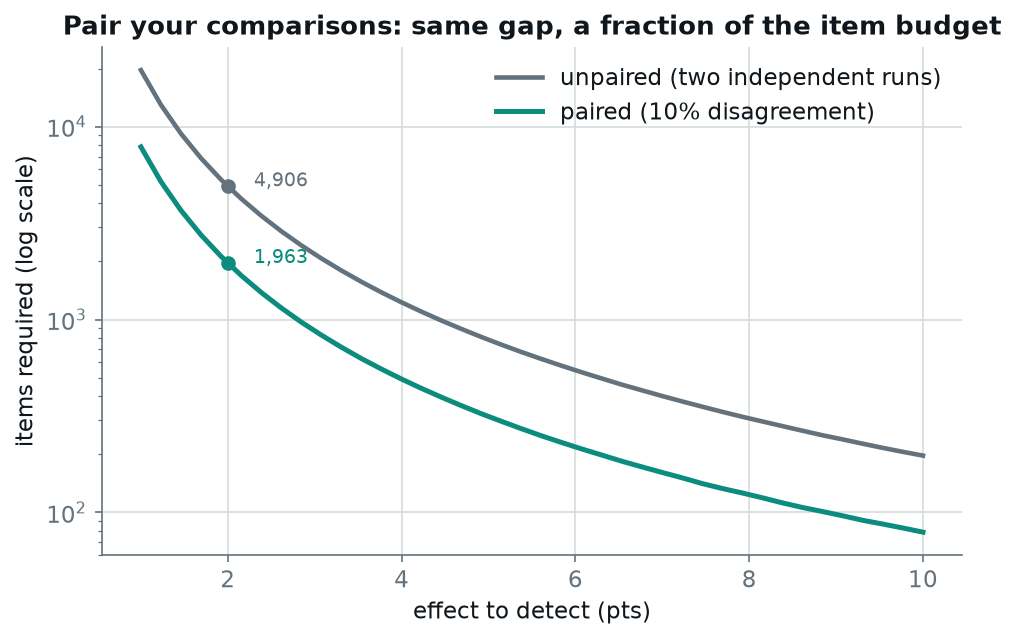

In [9]:
# Figure 5 : pairing pays. Items needed to resolve an effect, paired vs unpaired.
# Unpaired: per-item Bernoulli SD ~ 0.5 at p=0.5.
# Paired  : SD of per-item score differences ~ sqrt(disagreement rate); we assume 10%.
effects = np.linspace(1, 10, 40)  # in points
sigma_unpaired = np.sqrt(0.5 * 0.5)
disagreement = 0.10
sigma_paired = np.sqrt(disagreement)
n_unpaired = [stats.required_n(e / 100, sigma_unpaired) for e in effects]
n_paired = [stats.required_n(e / 100, sigma_paired) for e in effects]

fig, ax = plt.subplots(figsize=(7.4, 4.4))
ax.plot(effects, n_unpaired, color=MUTED, lw=2.2, label="unpaired (two independent runs)")
ax.plot(effects, n_paired, color=TEAL, lw=2.4, label="paired (10% disagreement)")
for e in (2.0,):
    nu = stats.required_n(e / 100, sigma_unpaired); npd = stats.required_n(e / 100, sigma_paired)
    ax.plot([e, e], [npd, nu], color=GRID, lw=1)
    ax.plot(e, nu, "o", color=MUTED); ax.plot(e, npd, "o", color=TEAL)
    ax.annotate(f"{nu:,}", (e, nu), xytext=(e + 0.3, nu), fontsize=9, color=MUTED)
    ax.annotate(f"{npd:,}", (e, npd), xytext=(e + 0.3, npd), fontsize=9, color=TEAL)
ax.set_yscale("log"); ax.set_xlabel("effect to detect (pts)")
ax.set_ylabel("items required (log scale)")
ax.set_title("Pair your comparisons: same gap, a fraction of the item budget")
ax.legend(loc="upper right", frameon=False)
save(fig, "fig5_paired_required_n.png"); plt.show()

summary["required_n_2pt"] = {"unpaired": stats.required_n(0.02, sigma_unpaired),
                             "paired_10pct_disagreement": stats.required_n(0.02, sigma_paired)}


## 4. Summary and reproducibility

Every number above was computed by the same functions the `assay` CLI calls, on the
same fixtures the test suite checks. The outputs are written to `results/` and the
figures are mirrored into `docs/figures/` so the project site shows exactly what this
notebook produced. Re-running this notebook regenerates all of them byte-for-byte
(the one stochastic step, the bootstrap SE, is seeded).

In [10]:
# Write the consolidated summary and confirm every artifact landed.
json.dump(summary, open(RESULTS / "summary.json", "w"), indent=2)

print("results/")
for p in sorted(RESULTS.rglob("*")):
    if p.is_file():
        print("  ", p.relative_to(ROOT))
print("\nheadline numbers")
print(f"  reconciler delta        : {summary['reconcile']['delta']*100:+.1f} pts (illustrative fixture)")
print(f"  SE inflation (clustered): {summary['clustering']['inflation']:.2f}x")
print(f"  noise floor @ n=200     : {summary['mde_n200_p0.7_pts']:.1f} pts")
print(f"  items for a 2pt gap     : {summary['required_n_2pt']['unpaired']:,} unpaired "
      f"vs {summary['required_n_2pt']['paired_10pct_disagreement']:,} paired")


results/
   results/check_mmlu_fixture.json
   results/figures/fig1_noise_floor_mde.png
   results/figures/fig2_error_bars.png
   results/figures/fig3_reconciler.png
   results/figures/fig4_subject_clusters.png
   results/figures/fig5_paired_required_n.png
   results/mde_table.csv
   results/reconcile_gsm8k.json
   results/summary.json

headline numbers
  reconciler delta        : +33.3 pts (illustrative fixture)
  SE inflation (clustered): 2.47x
  noise floor @ n=200     : 9.1 pts
  items for a 2pt gap     : 4,906 unpaired vs 1,963 paired
